In [1]:
import nmixup
import mix_utils

import numpy as np
import torch
import torchvision
import PIL
import matplotlib.pyplot as plt


In [556]:

BATCH_SIZE = 100
NUM_WORKERS = 8

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

base_trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)


Files already downloaded and verified
Files already downloaded and verified


In [557]:

testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [245]:

def show_np_array(arr):
    np_img_255 = np.uint8(arr*255)
    im = PIL.Image.fromarray(np.rollaxis(np_img_255.T, axis=1))
    plt.imshow(im)

def show_raw(arr):
    #np_img_255 = np.uint8(arr*255)
    im = PIL.Image.fromarray(arr)
    plt.imshow(im)
    
def mixup_data_np(imgs, lam_):
    imgs = (imgs * lam_).sum(axis=0)
    return imgs

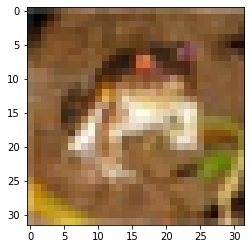

In [250]:
imgs_sample = base_trainset.data[:500]
imgs_sample = np.float32(imgs_sample/255.)
imgs_sample = imgs_sample.transpose((0, 3, 1, 2))

labels_sample = base_trainset.targets[:500]
#print(imgs_sample.shape, imgs_sample[0])
show_np_array(imgs_sample[0])

In [251]:

indices = mix_utils.buckets_intraclass(labels_sample, 3, 50)
print(indices.shape, indices[:, 0],
      base_trainset.classes[labels_sample[indices[0, 0]]],
      base_trainset.classes[labels_sample[indices[1, 0]]],
      base_trainset.classes[labels_sample[indices[2, 0]]])
ingredients = imgs_sample[indices]
ingredients.shape

(3, 50) [241  78 142] cat cat cat


(3, 50, 3, 32, 32)

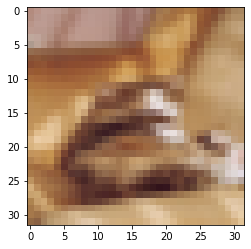

In [252]:
show_np_array(ingredients[0, 0])

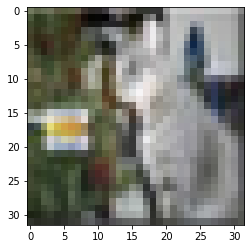

In [254]:
show_np_array(ingredients[1, 0])

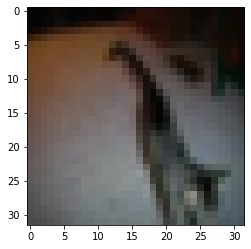

In [255]:
show_np_array(ingredients[2, 0])

In [402]:
lam_ = np.array([.5, .25, .25])
#imgs_m = (ingredients * lam_.reshape(1, 1, 3, 1, 1))

imgs_m = lam_.reshape(1, 1, 3, 1, 1) * ingredients
print(imgs_m.shape)
#imgs = imgs_m.sum(axis=0)
#imgs = np.swapaxes(imgs, 3, 1)

(3, 50, 3, 32, 32)


[[[0.46470588 0.46176472 0.477451   ... 0.49509805 0.5107843  0.47549024]
  [0.4264706  0.41078433 0.42352945 ... 0.5039216  0.5117647  0.4637255 ]
  [0.4294118  0.42254904 0.43039218 ... 0.5372549  0.5441176  0.49705884]
  ...
  [0.44607845 0.47352943 0.5264706  ... 0.6372549  0.64411765 0.6127451 ]
  [0.42450982 0.4166667  0.45098042 ... 0.59901965 0.6235294  0.60882354]
  [0.40490198 0.38333336 0.44117647 ... 0.54901963 0.5627451  0.5941177 ]]

 [[0.39705884 0.39509806 0.42058825 ... 0.42156863 0.4411765  0.40588236]
  [0.36764708 0.35588238 0.37156865 ... 0.43235296 0.4411765  0.39411768]
  [0.36666667 0.3637255  0.36666667 ... 0.47058827 0.477451   0.43039218]
  ...
  [0.36764708 0.39705884 0.45882356 ... 0.5980392  0.60784316 0.5745098 ]
  [0.3421569  0.3372549  0.3794118  ... 0.5519608  0.5803922  0.57058823]
  [0.327451   0.30490196 0.37549022 ... 0.4911765  0.50686276 0.5470588 ]]

 [[0.34411764 0.34607846 0.3745098  ... 0.34607846 0.36372548 0.3284314 ]
  [0.31862748 0.314705

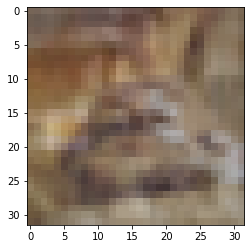

In [405]:
#show_np_array(imgs[0])
#print(ingredients[0, 0])
sum0_manual = .5*ingredients[0, 0] + .25*ingredients[1, 0] + .25*ingredients[2, 0]
print(sum0_manual)
show_np_array(sum0_manual)

In [406]:
lam_mask = np.concatenate([lam_[i] * np.ones((1, 50, 3, 32, 32)) for i in range(lam_.shape[0])], axis=0)

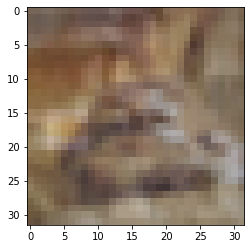

In [408]:
show_np_array((lam_mask * ingredients).sum(axis=0)[0])

In [ ]:

lam_ = np.array([.34, .33, .33])

base_set = base_trainset

N = lam_.shape[0]
L = 500
imgs = np.array(base_set.data[:L])
imgs = np.float32(imgs/255.)
imgs = imgs.transpose((0, 3, 1, 2))
labels = np.array(base_set.targets[:L])        

indices = mix_utils.buckets_intraclass(labels, N, L)
print(indices, indices.shape)
ingredients = imgs[indices]
        
print(imgs.shape)
lam_mask = np.concatenate([
    lam_[i] * np.ones((1, *imgs.shape))
    for i in range(lam_.shape[0])], axis=0)
        
mixed = (lam_mask * ingredients).sum(axis=0)
show_np_array(mixed[0])

class: ship


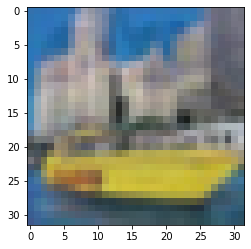

In [562]:
class IntraclassMixCIFAR10(torch.utils.data.Dataset):

    def __init__(self, base_set, lambda_vec, *, sample_size=None, transform=None):
        self.transform = transform        
        
        lam_ = lambda_vec

        N = lam_.shape[0]
        L = sample_size if sample_size else base_set.data.shape[0]
        imgs = np.array(base_set.data[:L])
        imgs = np.float32(imgs/255.)
        imgs = imgs.transpose((0, 3, 1, 2))
        labels = np.array(base_set.targets[:L])

        indices = mix_utils.buckets_intraclass(labels, N, L)
        ingredients = imgs[indices]

        lam_mask = np.concatenate([
            lam_[i] * np.ones((1, *imgs.shape))
            for i in range(lam_.shape[0])], axis=0)

        self.mixed = (lam_mask * ingredients).sum(axis=0)
        self.labels = labels[indices[0]]
        #show_np_array(mixed[0])
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        img = self.mixed[idx]
        target = self.labels[idx]
        
        if self.transform is not None:
            img = self.transform(img).transpose(1, 0).transpose(1, 2)
            if not img.shape == (3, 32, 32):
                raise Exception()
        return img, target
    
trainset = IntraclassMixCIFAR10(base_trainset,
                                np.array([.75, .2, .05]),
                                sample_size=50000,
                                transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

for imgs, targets in trainloader:
    print("class:", base_trainset.classes[targets[0]])
    show_np_array(imgs[0])
    break

## Training on intraclass

In [ ]:

from nmixup import resnet18, get_print
model_getter = resnet18

USE_CUDA = True
N_BATCHES = None
N_EPOCHS = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(base_testset) // BATCH_SIZE
print(N_BATCHES_IN_TRAIN_SET, N_BATCHES_IN_TEST_SET)
LR = .05
print_ = get_print(True, fname="results_intra")

test_accs = {}

device = torch.device('cuda' if USE_CUDA else 'cpu')
model = model_getter().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

lam_ = np.array([.34, .33, .33])
lam_tensor = torch.from_numpy(lam_).float().to(device)


model.train()

for epoch in range(1, N_EPOCHS + 1):
    print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
    for batch_id, (images, labels) in enumerate(trainloader):
        if N_BATCHES and batch_id > N_BATCHES:
            break
        labels, images = labels.to(device), images.to(device)
        outputs = model(images.float())
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_id % 50 == 0:
            print_('Loss :{:.4f} Epoch[{}/{}] Batch[{}/{}] batch_shape:{}'.format(
                loss.item(), epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET, images.shape))

# switch to evaluate mode
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    # Output test accuracy
    test_acc = 100 * correct / total
    print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
    
    test_accs[str(lam_)] = test_acc

del device, model, optimizer, criterion

test_accs

500 100
Epoch[1/100]
Loss :2.5896 Epoch[1/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :2.2633 Epoch[1/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.8917 Epoch[1/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.9417 Epoch[1/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.6172 Epoch[1/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.6052 Epoch[1/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5822 Epoch[1/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.5919 Epoch[1/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.3271 Epoch[1/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.4474 Epoch[1/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[2/100]
Loss :1.3914 Epoch[2/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :1.2907 Epoch[2/100] Batch[50/500] batch_shape:torch.Size([100, 

Loss :0.2696 Epoch[10/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[11/100]
Loss :0.1362 Epoch[11/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0811 Epoch[11/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0936 Epoch[11/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1789 Epoch[11/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0425 Epoch[11/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1712 Epoch[11/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1491 Epoch[11/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.2967 Epoch[11/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.2188 Epoch[11/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1709 Epoch[11/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[12/100]
Loss :0.1759 Epoch[12/100] Batch[0/500] batch_shape:torch.Size

Loss :0.0636 Epoch[20/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1224 Epoch[20/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0538 Epoch[20/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[21/100]
Loss :0.0579 Epoch[21/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0445 Epoch[21/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0065 Epoch[21/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0613 Epoch[21/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0635 Epoch[21/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0596 Epoch[21/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0639 Epoch[21/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0363 Epoch[21/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0243 Epoch[21/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32

Loss :0.0568 Epoch[30/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0092 Epoch[30/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0662 Epoch[30/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0898 Epoch[30/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0275 Epoch[30/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[31/100]
Loss :0.0194 Epoch[31/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0039 Epoch[31/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0071 Epoch[31/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0449 Epoch[31/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0468 Epoch[31/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0198 Epoch[31/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0312 Epoch[31/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32

Loss :0.0143 Epoch[40/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0940 Epoch[40/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0212 Epoch[40/100] Batch[250/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0042 Epoch[40/100] Batch[300/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0809 Epoch[40/100] Batch[350/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0124 Epoch[40/100] Batch[400/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0011 Epoch[40/100] Batch[450/500] batch_shape:torch.Size([100, 3, 32, 32])
Epoch[41/100]
Loss :0.0107 Epoch[41/100] Batch[0/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0076 Epoch[41/100] Batch[50/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0237 Epoch[41/100] Batch[100/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.0478 Epoch[41/100] Batch[150/500] batch_shape:torch.Size([100, 3, 32, 32])
Loss :0.1051 Epoch[41/100] Batch[200/500] batch_shape:torch.Size([100, 3, 32

...

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/queues.py", line 236, in _feed
    obj = _ForkingPickler.dumps(obj)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/queues.py", line 236, in _feed
    obj = _ForkingPickler.dumps(obj)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/queues.py", line 236, in _feed
    obj = _ForkingPickler.dumps(obj)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/queues.py", line 236, in _feed
    obj = _ForkingPickler.dumps(obj)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/queues.py", line 236, in _feed
    obj = _ForkingPickler.dumps(obj)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/reduction.py", line 51, in dumps
    

  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/resource_sharer.py", line 77, in register
    self._start()
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 432, in __init__
    address = address or arbitrary_address(family)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 76, in arbitrary_address
    return tempfile.mktemp(prefix='listener-', dir=util.get_temp_dir())
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 432, in __init__
    address = address or arbitrary_address(family)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 76, in arbitrary_address
    return tempfile.mktemp(prefix='listener-', dir=util.get_temp_dir())
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/resource_sharer.py", line 130, in _start
    self._listener = Listener(authkey=process.current_process().authkey)
  File "/data/landelle/anaconda3/l

  File "/data/landelle/anaconda3/lib/python3.7/tempfile.py", line 229, in _get_default_tempdir
    dirlist)
FileNotFoundError: [Errno 2] No usable temporary directory found in ['/tmp', '/var/tmp', '/usr/tmp', '/home/landelle/mixup/clean']
Traceback (most recent call last):
  File "/data/landelle/anaconda3/lib/python3.7/tempfile.py", line 229, in _get_default_tempdir
    dirlist)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/reduction.py", line 51, in dumps
    cls(buf, protocol).dump(obj)
FileNotFoundError: [Errno 2] No usable temporary directory found in ['/tmp', '/var/tmp', '/usr/tmp', '/home/landelle/mixup/clean']
Traceback (most recent call last):
Traceback (most recent call last):
  File "/data/landelle/anaconda3/lib/python3.7/tempfile.py", line 294, in gettempdir
    tempdir = _get_default_tempdir()
  File "/data/landelle/anaconda3/lib/python3.7/site-packages/torch/multiprocessing/reductions.py", line 327, in reduce_storage
    df = multiprocessing.reduction.DupF

  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 76, in arbitrary_address
    return tempfile.mktemp(prefix='listener-', dir=util.get_temp_dir())
  File "/data/landelle/anaconda3/lib/python3.7/tempfile.py", line 356, in mkdtemp
    prefix, suffix, dir, output_type = _sanitize_params(prefix, suffix, dir)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 432, in __init__
    address = address or arbitrary_address(family)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/resource_sharer.py", line 77, in register
    self._start()
  File "/data/landelle/anaconda3/lib/python3.7/site-packages/torch/multiprocessing/reductions.py", line 327, in reduce_storage
    df = multiprocessing.reduction.DupFd(fd)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/util.py", line 114, in get_temp_dir
    tempdir = tempfile.mkdtemp(prefix='pymp-')
  File "/data/landelle/anaconda3/lib/python3.7/tempfile.py", line 3

  File "/data/landelle/anaconda3/lib/python3.7/tempfile.py", line 294, in gettempdir
    tempdir = _get_default_tempdir()
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/resource_sharer.py", line 130, in _start
    self._listener = Listener(authkey=process.current_process().authkey)
  File "/data/landelle/anaconda3/lib/python3.7/tempfile.py", line 229, in _get_default_tempdir
    dirlist)
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 432, in __init__
    address = address or arbitrary_address(family)
FileNotFoundError: [Errno 2] No usable temporary directory found in ['/tmp', '/var/tmp', '/usr/tmp', '/home/landelle/mixup/clean']
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/connection.py", line 76, in arbitrary_address
    return tempfile.mktemp(prefix='listener-', dir=util.get_temp_dir())
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/util.py", line 114, in get_temp_dir
    tempdir = tempfile.mkdtemp